In [152]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [153]:
df = pd.read_csv("data/bioactivity_preprocessed_data.csv")
df

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,7200.0,intermediate
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,9400.0,intermediate
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,13500.0,inactive
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,13110.0,inactive
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],2000.0,intermediate
...,...,...,...,...
252,CHEMBL2311740,CC(C)(C)NC(=O)[C@@H](c1cccnc1)N(C(=O)c1ccco1)c...,1500.0,active
253,CHEMBL5563508,C=CC(=O)N[C@H](CC(=C)C)C(=O)N1C[C@@H](C(=O)N[C...,3500.0,active
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,52.0,active
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,30.0,active


Calculate Lipinski descriptors

In [154]:

# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [155]:
df_lipinski = lipinski(df.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,281.271,1.89262,0.0,5.0
1,415.589,3.81320,0.0,2.0
2,421.190,2.66050,0.0,4.0
3,293.347,3.63080,0.0,3.0
4,338.344,3.53900,0.0,5.0
...,...,...,...,...
252,433.552,5.27490,1.0,4.0
253,584.639,3.35790,3.0,4.0
254,436.512,1.47440,3.0,4.0
255,496.583,2.73690,3.0,4.0


MW (Molecular Weight) = size \
LogP = solubility \
NumHDonors = # hydrogen bond donors \
NumHAcceptors = # hydrogen bond acceptors

In [156]:
df_combined = pd.concat([df, df_lipinski], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,7200.0,intermediate,281.271,1.89262,0.0,5.0
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,9400.0,intermediate,415.589,3.81320,0.0,2.0
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,13500.0,inactive,421.190,2.66050,0.0,4.0
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,13110.0,inactive,293.347,3.63080,0.0,3.0
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],2000.0,intermediate,338.344,3.53900,0.0,5.0
...,...,...,...,...,...,...,...,...
252,CHEMBL2311740,CC(C)(C)NC(=O)[C@@H](c1cccnc1)N(C(=O)c1ccco1)c...,1500.0,active,433.552,5.27490,1.0,4.0
253,CHEMBL5563508,C=CC(=O)N[C@H](CC(=C)C)C(=O)N1C[C@@H](C(=O)N[C...,3500.0,active,584.639,3.35790,3.0,4.0
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,52.0,active,436.512,1.47440,3.0,4.0
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,30.0,active,496.583,2.73690,3.0,4.0


**Convert IC50 to pIC50** \
pIC50 is more uniformly distributed \
pIC50 = -log10(IC50)

In [157]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

def pIC50(input):
    pIC50 = []

    for i in input['standard_value']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value', axis=1)
        
    return x

In [158]:
df_final = pIC50(df_combined)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,281.271,1.89262,0.0,5.0,5.142668
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,415.589,3.81320,0.0,2.0,5.026872
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,421.190,2.66050,0.0,4.0,4.869666
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,293.347,3.63080,0.0,3.0,4.882397
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,338.344,3.53900,0.0,5.0,5.698970
...,...,...,...,...,...,...,...,...
252,CHEMBL2311740,CC(C)(C)NC(=O)[C@@H](c1cccnc1)N(C(=O)c1ccco1)c...,active,433.552,5.27490,1.0,4.0,5.823909
253,CHEMBL5563508,C=CC(=O)N[C@H](CC(=C)C)C(=O)N1C[C@@H](C(=O)N[C...,active,584.639,3.35790,3.0,4.0,5.455932
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,436.512,1.47440,3.0,4.0,7.283997
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,active,496.583,2.73690,3.0,4.0,7.522879


In [159]:
df_final.pIC50.describe()

count    257.000000
mean       4.984016
std        0.996327
min        2.698970
25%        4.346787
50%        4.853872
75%        5.420216
max        7.853872
Name: pIC50, dtype: float64

In [160]:
# Remove intermediate bioactivity class
df_2class = df_final[df_final.bioactivity_class != "intermediate"]
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,421.190,2.6605,0.0,4.0,4.869666
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,293.347,3.6308,0.0,3.0,4.882397
5,CHEMBL365134,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c(Br)cccc21,active,372.243,4.3933,0.0,3.0,6.008774
7,CHEMBL190743,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccc(I)cc21,active,419.243,4.2354,0.0,3.0,6.022276
8,CHEMBL365469,O=C1C(=O)N(Cc2cc3ccccc3s2)c2cccc(Cl)c21,inactive,327.792,4.2842,0.0,3.0,4.950782
...,...,...,...,...,...,...,...,...
252,CHEMBL2311740,CC(C)(C)NC(=O)[C@@H](c1cccnc1)N(C(=O)c1ccco1)c...,active,433.552,5.2749,1.0,4.0,5.823909
253,CHEMBL5563508,C=CC(=O)N[C@H](CC(=C)C)C(=O)N1C[C@@H](C(=O)N[C...,active,584.639,3.3579,3.0,4.0,5.455932
254,CHEMBL5595277,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,436.512,1.4744,3.0,4.0,7.283997
255,CHEMBL5570210,CC(C)c1ccc(F)c2[nH]c(C(=O)N3C[C@H]4[C@@H]([C@H...,active,496.583,2.7369,3.0,4.0,7.522879


**Chemical Space Analysis**

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='ticks')

Frequency plot of the 2 bioactivity classes

Text(0, 0.5, 'Frequency')

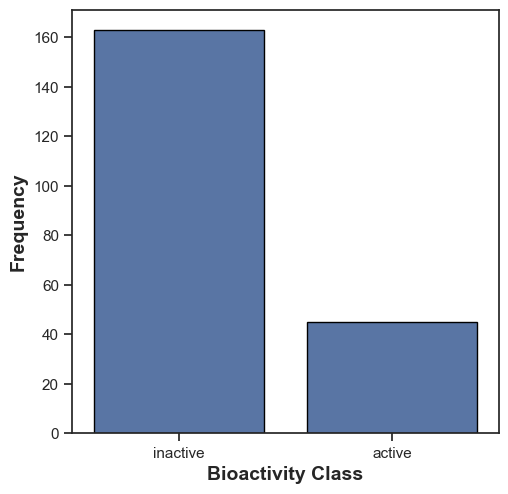

In [162]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

In [163]:
plt.savefig('results/plot_bioactivity_class.pdf')

<Figure size 640x480 with 0 Axes>

Scatter plot of MW versus LogP

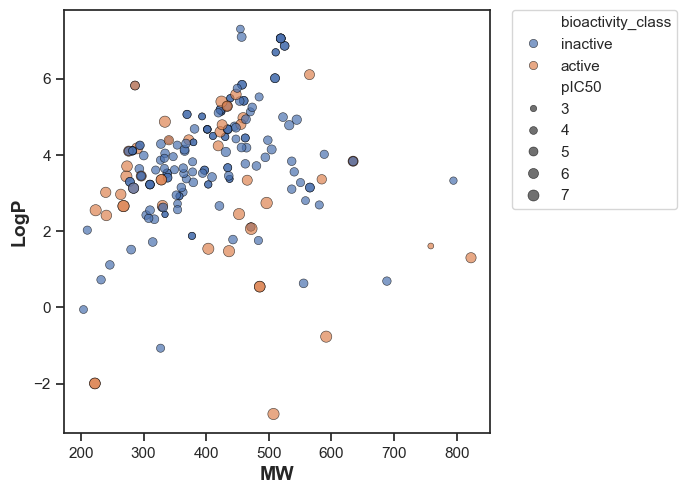

In [164]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x="MW", y="LogP", data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

In [165]:
plt.savefig('results/plot_MW_vs_LogP.pdf')

<Figure size 640x480 with 0 Axes>

pIC50 Box Plot

Text(0, 0.5, 'pIC50 Value')

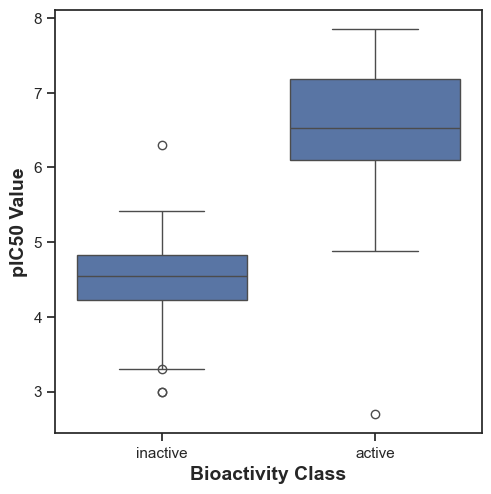

In [166]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='pIC50', data=df_2class)

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 Value', fontsize=14, fontweight='bold')

In [167]:
plt.savefig('results/plot_pIC50.pdf')

<Figure size 640x480 with 0 Axes>

In [168]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df['bioactivity_class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df['bioactivity_class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(f'results/{filename}')

  return results

In [169]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,7122.5,4.152043e-22,0.05,Different distribution (reject H0)


MW Box Plot

Text(0, 0.5, 'MW')

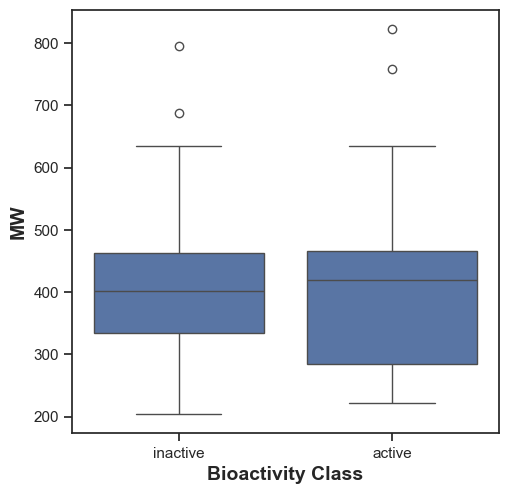

In [170]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='MW', data=df_2class)

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

In [171]:
plt.savefig('results/plot_MW.pdf')

<Figure size 640x480 with 0 Axes>

In [172]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,3288.5,0.289598,0.05,Same distribution (fail to reject H0)


LogP Box Plot

Text(0, 0.5, 'LogP')

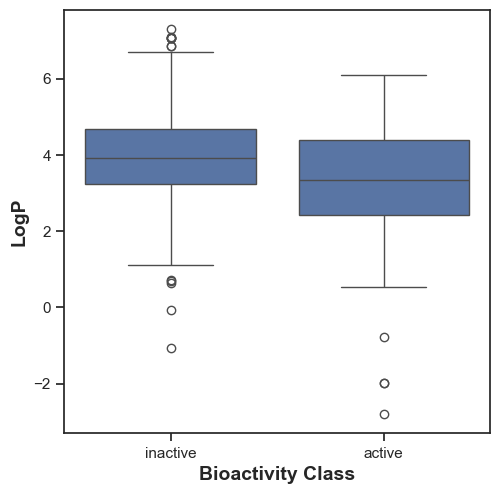

In [173]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='LogP', data=df_2class)

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

In [174]:
plt.savefig('results/plot_LogP.pdf')

<Figure size 640x480 with 0 Axes>

In [175]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,2741.5,0.009613,0.05,Different distribution (reject H0)


NumHDonors Box Plot

Text(0, 0.5, 'NumHDonors')

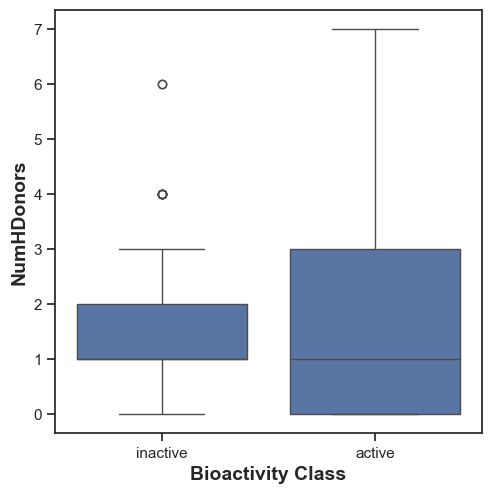

In [176]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='NumHDonors', data=df_2class)

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

In [177]:
plt.savefig('results/plot_NumHDonors.pdf')

<Figure size 640x480 with 0 Axes>

In [178]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3325.5,0.320377,0.05,Same distribution (fail to reject H0)


NumHAcceptors Box Plot

Text(0, 0.5, 'NumHAcceptors')

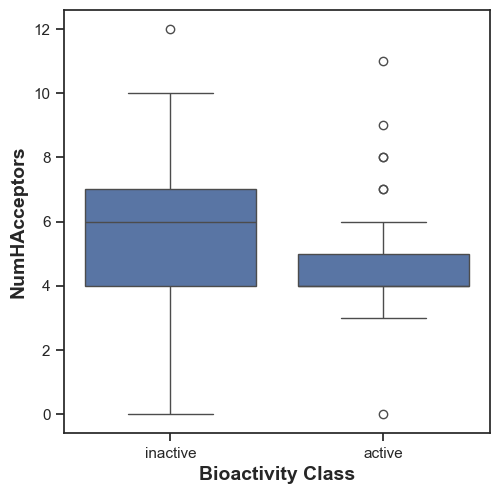

In [179]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='NumHAcceptors', data=df_2class)

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

In [180]:
plt.savefig('results/plot_NumHAcceptors.pdf')

<Figure size 640x480 with 0 Axes>

In [181]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,2623.5,0.003043,0.05,Different distribution (reject H0)


**Interpretation of Statistical Results** \
pIC50 Values: \
Actives and inactives displayed statistically significant difference for pIC50, which is to be expected since threshold values (IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives, corresponding to pIC50 > 6 = Actives and pIC50 < 5 = Inactives) were used to define actives and inactives.

Lipinski's descriptors: \
Only 2/4 Lipinski's descriptors (LogP and NumHAcceptors) exhibited statistically significant difference between the actives and inactives.